# Rain Forecasting

# End to End Macgine Learning Pipeline

## Business Problem

A prominent water management company in Mumbai requires accurate rainfall forecasting to improve water allocation, reservoir storage planning, and distribution strategies.

Since Mumbai heavily depends on seasonal rainfall, accurate forecasting can help optimize water resource management, reduce operational costs, and ensure a reliable water supply for residents and industries.

## Project Objective

The objective of this project is to develop a machine learning-based rainfall forecasting model using historical rainfall data for Mumbai, India.

The model aims to predict upcoming monthly rainfall patterns, enabling proactive decision-making for water conservation, infrastructure maintenance, and drought preparedness.

# Import Libraries 

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.signal import savgol_filter
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import RandomizedSearchCV
import shap
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

## Data Overview
In this step, we load the dataset and perform an initial inspection to understand its dimensions, data types, and basic structure.

In [2]:
# Load the dataset
df = pd.read_csv("mumbai-monthly-rains.csv")

In [3]:
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250


In [4]:
# Check the shape of the data
df.shape

(121, 14)

In [5]:
df.columns

Index(['Year', 'Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug',
       'Sept', 'Oct', 'Nov', 'Dec', 'Total'],
      dtype='object')

In [6]:
# Display dataset information (Columns, Dtypes, Memory)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    121 non-null    int64  
 1   Jan     121 non-null    float64
 2   Feb     121 non-null    float64
 3   Mar     121 non-null    float64
 4   April   121 non-null    float64
 5   May     121 non-null    float64
 6   June    121 non-null    float64
 7   July    121 non-null    float64
 8   Aug     121 non-null    float64
 9   Sept    121 non-null    float64
 10  Oct     121 non-null    float64
 11  Nov     121 non-null    float64
 12  Dec     121 non-null    float64
 13  Total   121 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 13.4 KB


## Data Summary
Before model development, an initial data quality assessment was performed to understand the reliability and structure of the rainfall dataset.
The following checks were conducted:

- **Missing Values:** Identify any gaps or missing observations in the historical rainfall records.
- **Distribution Analysis:** Examine rainfall patterns across years and identify unusually high or low rainfall values (potential outliers).
- **Data Consistency:** Confirm that the dataset structure, date formatting, and rainfall measurements are suitable for analysis.

In [7]:
#  Check for Missing Values
df.isnull().sum()

Year     0
Jan      0
Feb      0
Mar      0
April    0
May      0
June     0
July     0
Aug      0
Sept     0
Oct      0
Nov      0
Dec      0
Total    0
dtype: int64

In [8]:
#  Statistical Summary (Descriptive Stats)
df.describe()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
count,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,1961.000000,1.567235,0.929358,0.869231,1.428458,18.183632,517.854402,757.407412,465.600818,312.885747,73.983526,13.849462,3.556428,2168.115709
std,35.073732,6.462247,3.077050,2.890032,7.371307,48.628812,251.067016,285.836188,249.072915,205.135368,96.686113,29.689941,12.342390,533.263926
min,1901.000000,0.000000,0.000000,0.000000,0.000000,0.000000,61.058662,103.209194,87.493370,36.313545,0.000000,0.000000,0.000000,1058.840525
25%,1931.000000,0.000000,0.000000,0.000000,0.000000,0.000000,324.094617,540.745923,268.002392,149.584208,9.871696,0.000000,0.000000,1834.996957
50%,1961.000000,0.000000,0.000000,0.000000,0.000000,0.355001,482.449872,788.403637,445.870342,269.276549,43.479170,1.066086,0.000000,2126.054987
75%,1991.000000,0.000000,0.152298,0.000000,0.194165,4.208322,678.040770,942.616099,604.372615,398.645218,98.235161,9.373154,0.176149,2478.558089
max,2021.000000,51.348290,21.107118,18.252996,75.541818,234.392757,1219.518576,1358.833554,1200.956558,987.796660,552.902707,164.348387,90.044602,3563.259531


In [9]:
# check duplicates 
df.duplicated().sum()

np.int64(0)

In [10]:
# Original dataset in wide format
df_wide = df.copy()

In [11]:
# List monthly rainfall columns and create month-to-number mapping for date conversion
month_cols = ['Jan', 'Feb', 'Mar', 'April', 'May', 'June', 'July', 'Aug',
       'Sept', 'Oct', 'Nov', 'Dec']
month_map = {'Jan':1, 'Feb':2, 'Mar':3, 'April':4, 'May':5, 'June':6,
              'July':7, 'Aug':8, 'Sept':9, 'Oct':10, 'Nov':11, 'Dec':12}

In [12]:
# Reshape monthly rainfall data from wide to long format
df_long = df_wide.melt(
    id_vars='Year',
    value_vars=month_cols,
    var_name='MonthName',
    value_name='rainfall_mm'
)

In [13]:
df_long.head()

,Year,MonthName,rainfall_mm
0,1901,Jan,13.116602
1,1902,Jan,0.000000
2,1903,Jan,0.000000
3,1904,Jan,0.000000
4,1905,Jan,0.662561


In [14]:
# Convert month names to numeric month values
df_long['month_num']=df_long['MonthName'].map(month_map)

In [15]:
# Create datetime column from year and month values
df_long['date']=pd.to_datetime(
    df_long['Year'].astype(str)+'-'+
    df_long['month_num'].astype(str),
    format='%Y-%m'
)

In [16]:
# Preview year, month, and generated date columns
df_long[['Year','MonthName','date']].head()

,Year,MonthName,date
0,1901,Jan,1901-01-01
1,1902,Jan,1902-01-01
2,1903,Jan,1903-01-01
3,1904,Jan,1904-01-01
4,1905,Jan,1905-01-01


In [17]:
# Sort data by date and set datetime as index
df_long=df_long.sort_values('date').set_index('date')[['rainfall_mm']]

In [18]:
print('Date Range:',df_long.index.min().date(),
      '→',
      df_long.index.max().date()
     )
print('Total records:', len(df_long))
df_long.head(15)

Date Range: 1901-01-01 → 2021-12-01
Total records: 1452


,rainfall_mm
date,
1901-01-01,13.116602
1901-02-01,0.000000
1901-03-01,0.000000
1901-04-01,3.949669
1901-05-01,17.139791
1901-06-01,640.714036
1901-07-01,888.369692
1901-08-01,545.045796
1901-09-01,64.271513


In [19]:
annual = df['Total']
wettest_idx = annual.idxmax()
driest_idx = annual.idxmin()

print("Wettest Year:", df.loc[wettest_idx, 'Year'], annual.max())
print("Driest Year:", df.loc[driest_idx, 'Year'], annual.min())

Wettest Year: 2020 3563.259531
Driest Year: 1941 1058.840525


## Exploratory Data Analysis (EDA)
Visualizing the data to uncover hidden patterns, trends, and seasonality.

### Monthly Rainfall Pattern Analysis

Examine long-term seasonal and rainfall variability patterns in Mumbai’s monthly rainfall data.

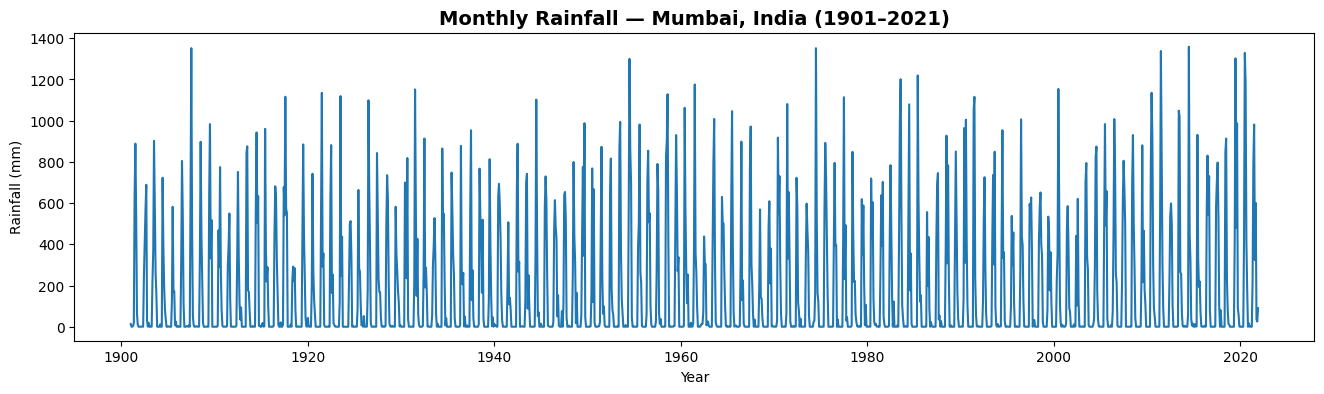

In [20]:
plt.figure(figsize=(16, 4))

plt.plot(df_long.index, df_long['rainfall_mm'])

plt.title('Monthly Rainfall — Mumbai, India (1901–2021)',fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Rainfall (mm)')

plt.show()

 ###  Monthly Seasonality Analysis
 Average rainfall is highly concentrated during the monsoon season (June–September), with July showing the highest average rainfall, while the remaining months receive relatively low rainfall.

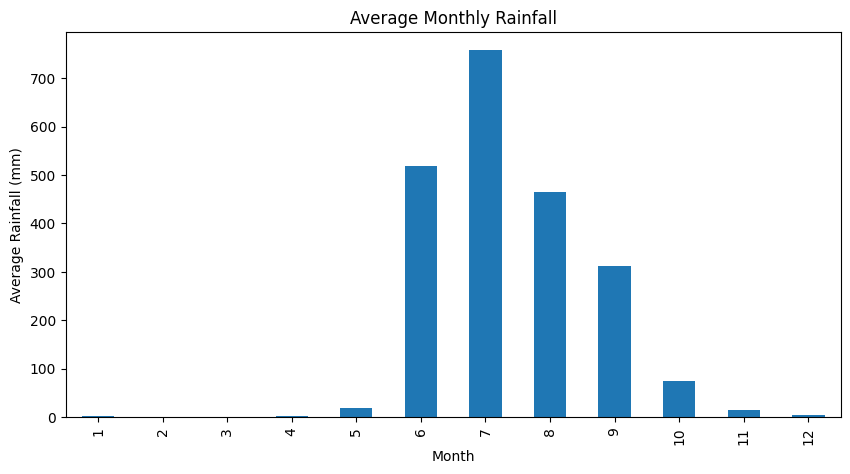

In [21]:
monthly_avg = df_long.groupby(df_long.index.month)['rainfall_mm'].mean()

plt.figure(figsize=(10,5))

monthly_avg.plot(kind='bar')

plt.title('Average Monthly Rainfall')
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')

plt.show()

## Seasonality & Monthly Distribution
 Identify the months with the highest rainfall variability.

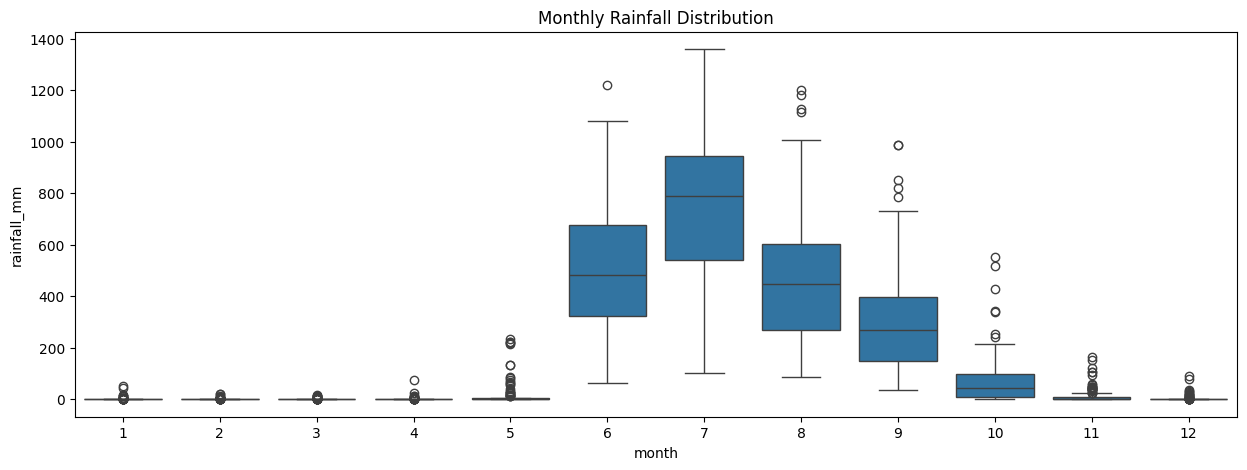

In [22]:
df_long['month'] = df_long.index.month

plt.figure(figsize=(15,5))

sns.boxplot(
    x='month',
    y='rainfall_mm',
    data=df_long
)

plt.title('Monthly Rainfall Distribution')

plt.show()

## Annual Rainfall Trend Analysis

Examine year-to-year fluctuations and long-term patterns in Mumbai’s total annual rainfall to understand historical variability, identify unusually wet or dry years, and assess overall rainfall behavior over time.

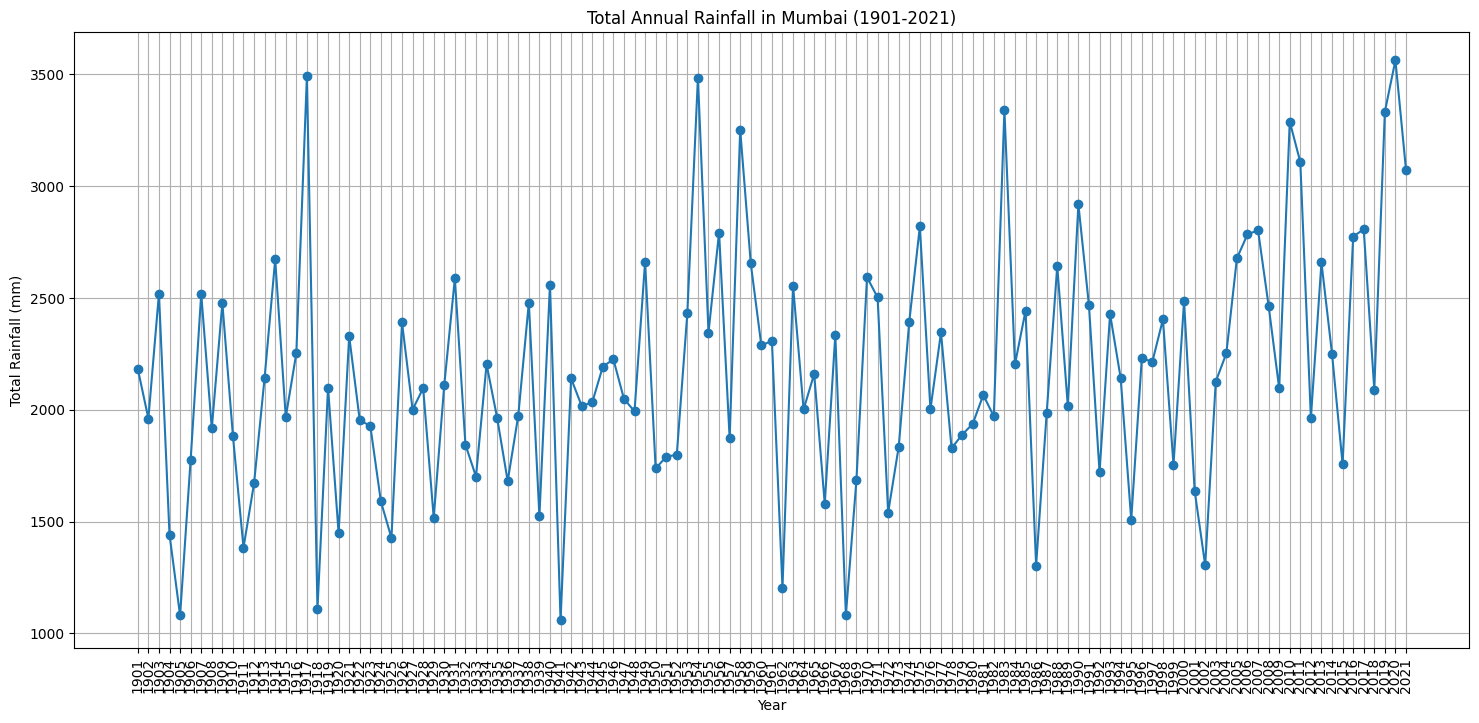

In [23]:
plt.figure(figsize=(18, 8))
plt.plot(df['Year'], df['Total'], marker='o')
plt.title('Total Annual Rainfall in Mumbai (1901-2021)')
plt.xlabel('Year')
plt.ylabel('Total Rainfall (mm)')
plt.grid()
plt.xticks(df['Year'], rotation=90)
plt.show()

## Seasonal Rainfall Contribution Analysis

Analyze rainfall distribution across major seasonal periods to understand which season contributes most significantly to Mumbai’s overall rainfall patterns.

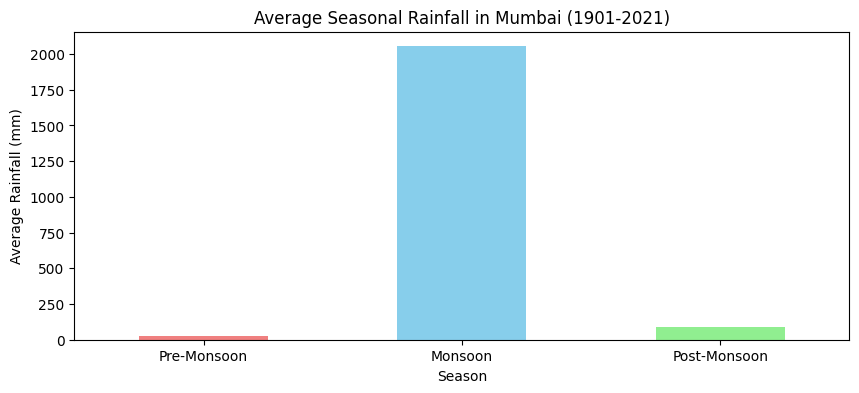

In [24]:
seasons = {
    'Pre-Monsoon': df[['Jan', 'Feb', 'Mar', 'April', 'May']].sum(axis=1),
    'Monsoon': df[['June', 'July', 'Aug', 'Sept']].sum(axis=1),
    'Post-Monsoon': df[['Oct', 'Nov', 'Dec']].sum(axis=1)
}
seasonal_data = pd.DataFrame(seasons)
seasonal_means = seasonal_data.mean()
plt.figure(figsize=(10, 4))
seasonal_means.plot(kind='bar', color=['lightcoral', 'skyblue', 'lightgreen'])
plt.title('Average Seasonal Rainfall in Mumbai (1901-2021)')
plt.ylabel('Average Rainfall (mm)')
plt.xlabel('Season')
plt.xticks(rotation= 0)
plt.show()

## Rainfall Intensity Heatmap

Analyze how  monsoon rainfall intensity varied across the historical period?

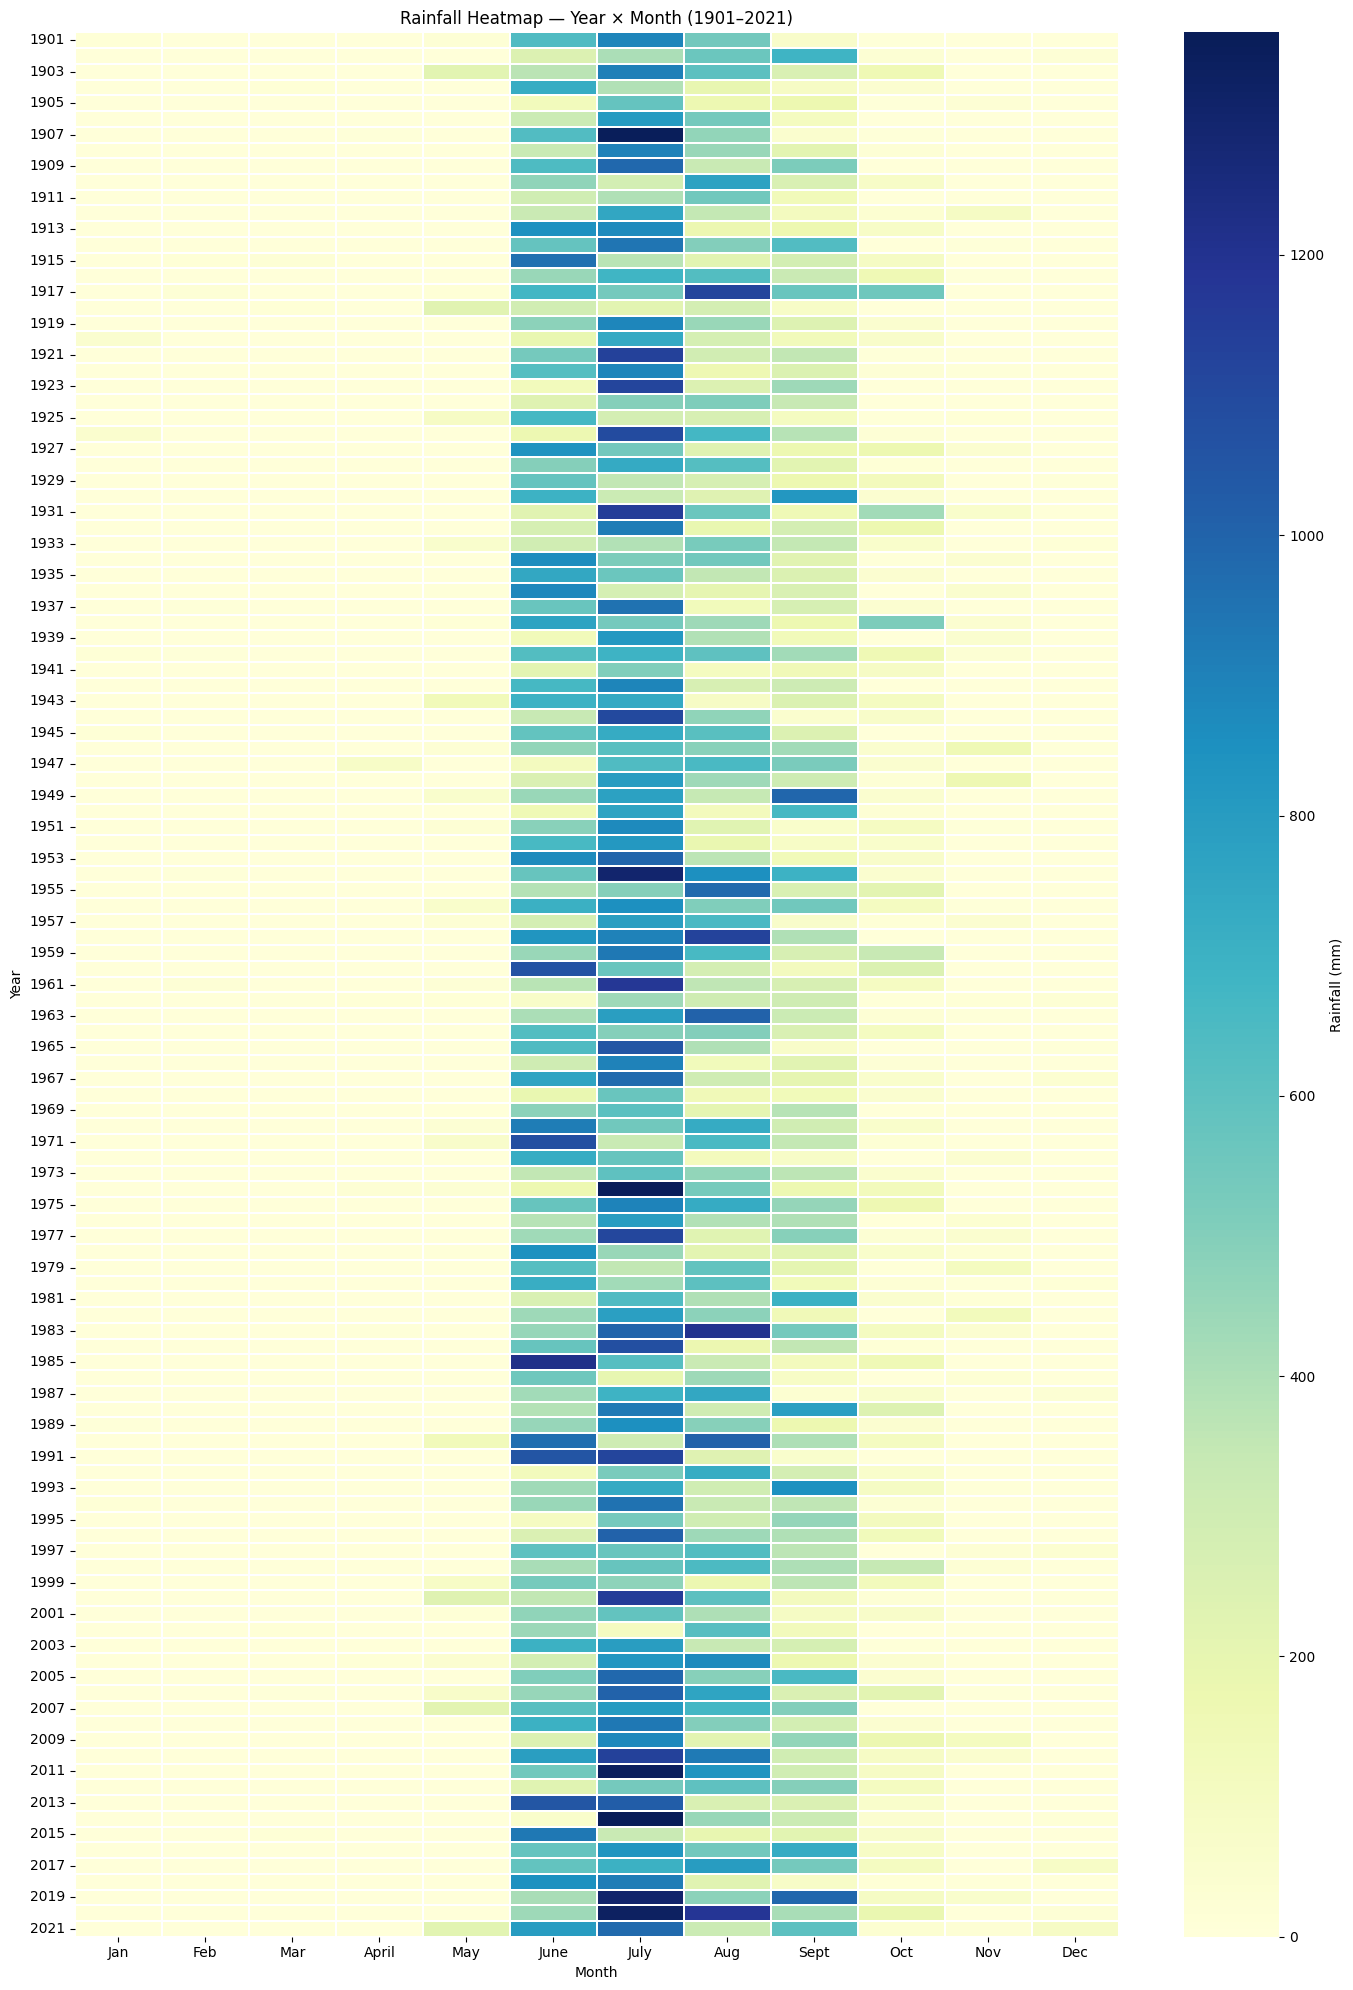

In [25]:
pivot = df_wide.set_index('Year')[month_cols].copy()
plt.figure(figsize=(14,20))

sns.heatmap(
    pivot,
    cmap='YlGnBu',
    linewidths=0.15,
    cbar_kws={'label': 'Rainfall (mm)'}
)

plt.title('Rainfall Heatmap — Year × Month (1901–2021)')
plt.xlabel('Month')
plt.ylabel('Year')

plt.tight_layout()

plt.show()

 ## Correlation Matrix
 Examine whether heavy rainfall in one monsoon month is associated with higher rainfall in subsequent months.

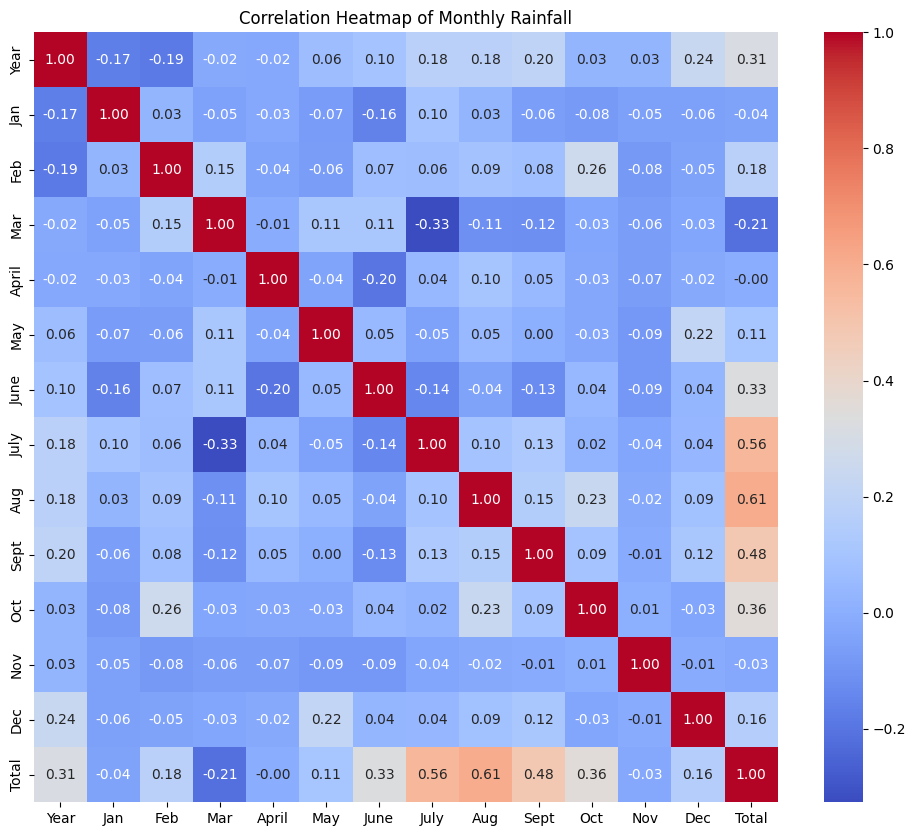

In [26]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Monthly Rainfall')
plt.show()

## Long-Term Rainfall Trend Decomposition

Analyze long-term rainfall trends, underlying smooth patterns, and residual fluctuations to understand historical changes in Mumbai’s annual rainfall behavior.

Long-term trend: +4.78 mm/year  (+579 mm over 121 years)


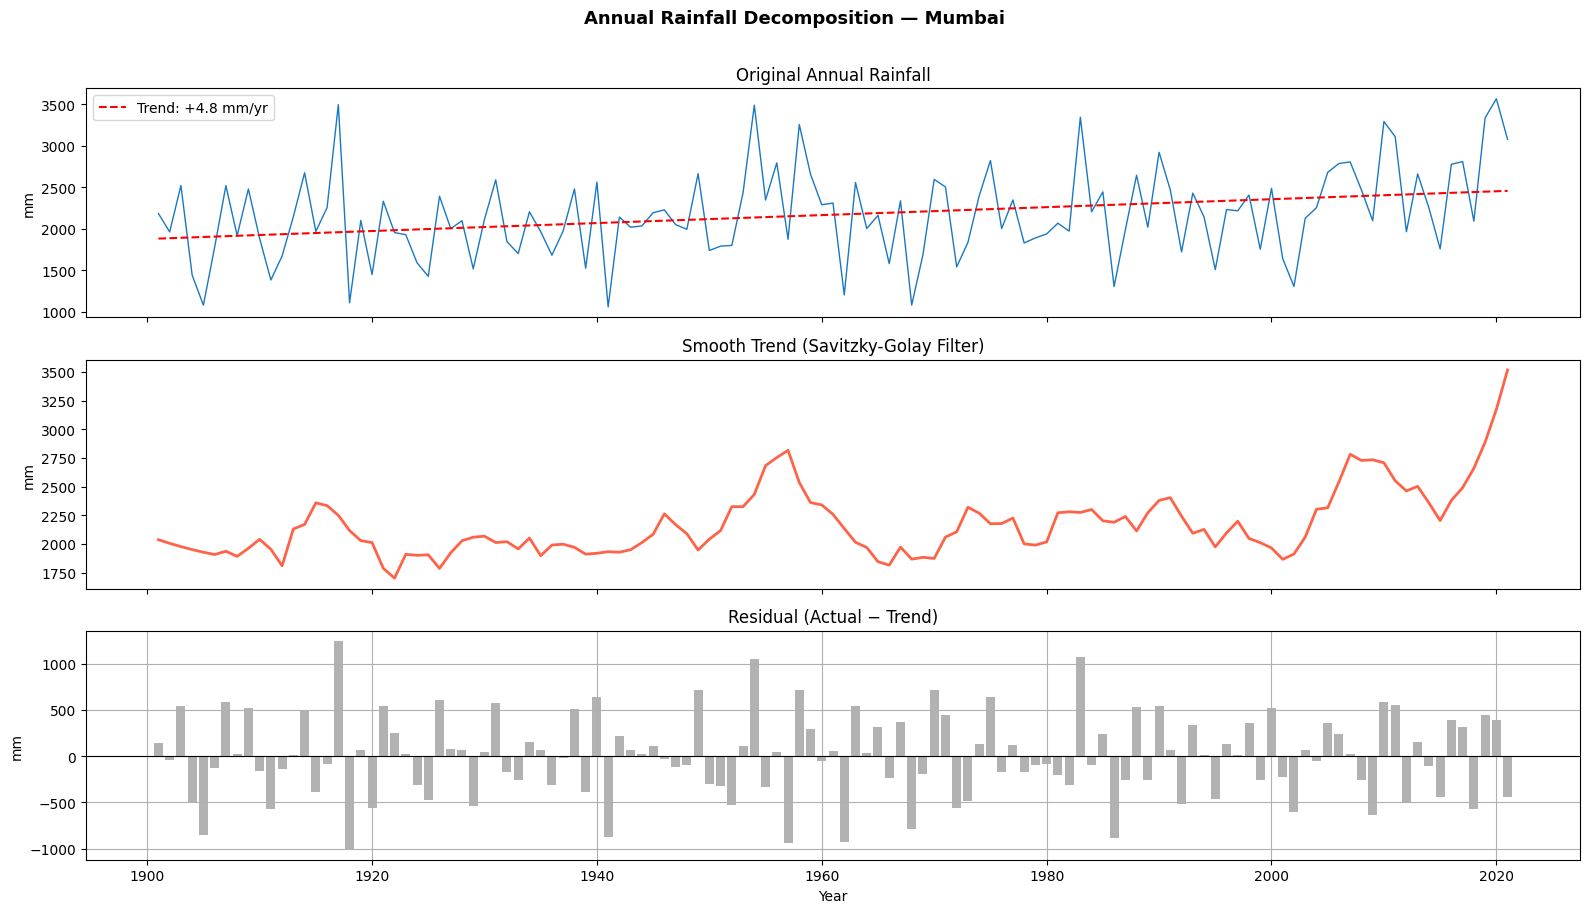

In [27]:
annual = df_long.groupby(
    df_long.index.year
)['rainfall_mm'].sum()
years  = annual.index.values
values = annual.values
trend  = savgol_filter(values, window_length=11, polyorder=2)
residual = values - trend

# Linear trend
slope, intercept = np.polyfit(years, values, 1)
print(f'Long-term trend: {slope:+.2f} mm/year  ({slope*121:+.0f} mm over 121 years)')

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)

axes[0].plot(years, values, color='#1a78c2', linewidth=1)
axes[0].plot(years, slope*years + intercept, 'r--', linewidth=1.5,
             label=f'Trend: {slope:+.1f} mm/yr')
axes[0].legend()
axes[0].set_title('Original Annual Rainfall')
axes[0].set_ylabel('mm')


axes[1].plot(years, trend, color='tomato', linewidth=2)
axes[1].set_title('Smooth Trend (Savitzky-Golay Filter)')
axes[1].set_ylabel('mm')

axes[2].bar(years, residual, color='gray', alpha=0.6)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title('Residual (Actual − Trend)')
axes[2].set_ylabel('mm')
axes[2].set_xlabel('Year')

fig.suptitle('Annual Rainfall Decomposition — Mumbai', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Rainfall Distribution Analysis

Understand how annual rainfall values are distributed over time, identify the average rainfall level, and assess whether the data follows a normal distribution.

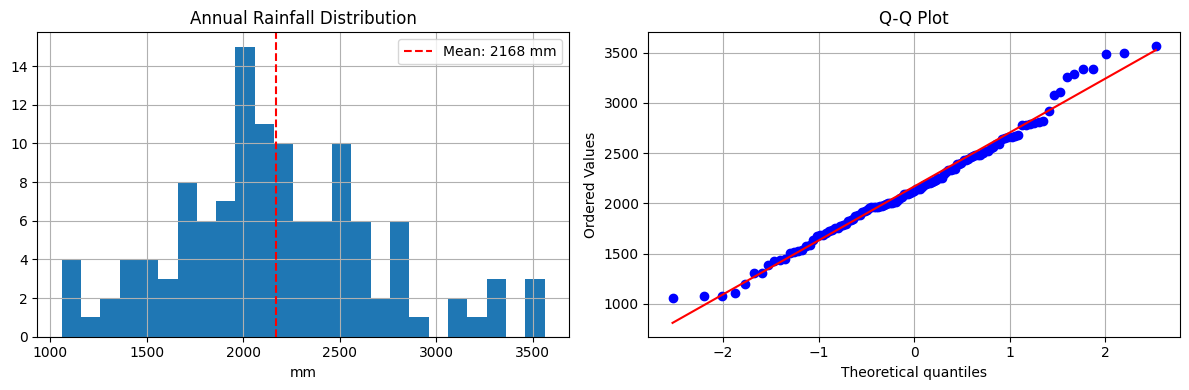

In [28]:
# Create Graphs
fig, axes = plt.subplots(1, 2,figsize=(12,4))
# Histogram
axes[0].hist(annual,bins=25)
axes[0].axvline(
    annual.mean(),
    color='red',
    linestyle='--',
    label=f'Mean: {annual.mean():.0f} mm'
)

axes[0].set_title('Annual Rainfall Distribution')

axes[0].set_xlabel('mm')

axes[0].legend()

axes[0].grid(True)

# Q-Q Plot

stats.probplot(
    annual,
    dist='norm',
    plot=axes[1]
)

axes[1].set_title('Q-Q Plot')
axes[1].grid(True)
plt.tight_layout()

plt.show()

## Decade-wise Rainfall Pattern Analysis

Analyze how monthly rainfall patterns have changed across different decades to identify shifts in seasonal rainfall behavior over time.

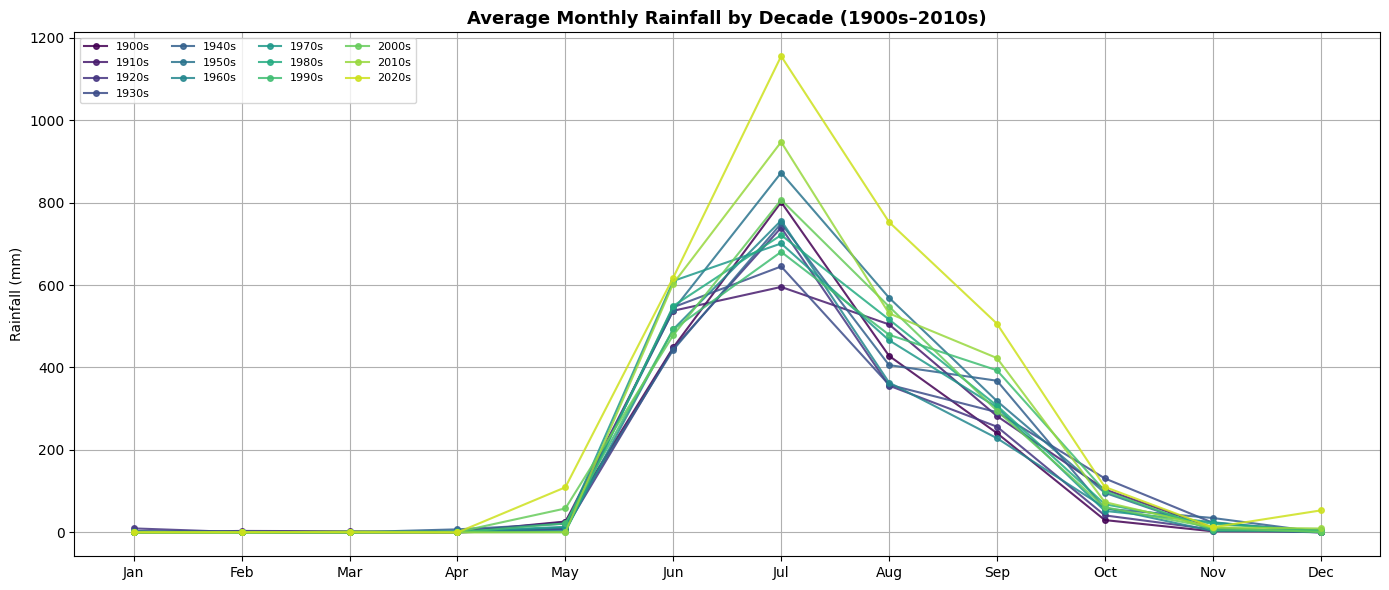

In [29]:
df['decade'] = (df['Year'] // 10) * 10
decade_avg = df.groupby('decade')[month_cols].mean()
decade_avg.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, ax = plt.subplots(figsize=(14, 6))
cmap = plt.cm.viridis
for i, (decade, row) in enumerate(decade_avg.iterrows()):
    color = cmap(i / len(decade_avg))
    ax.plot(range(12), row.values, marker='o', markersize=4,
            label=f'{int(decade)}s', linewidth=1.5, alpha=0.85, color=color)
ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title('Average Monthly Rainfall by Decade (1900s–2010s)', fontsize=13, fontweight='bold')
ax.set_ylabel('Rainfall (mm)')
ax.legend(ncol=4, fontsize=8, loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()
     

In [30]:
# Calculate quartiles and IQR for annual rainfall
Q1  = annual.quantile(0.25)
Q3  = annual.quantile(0.75)
IQR = Q3 - Q1

# Identify extreme rainfall years using IQR outlier rule
outliers = annual[(annual < Q1 - 1.5*IQR) | (annual > Q3 + 1.5*IQR)]

# Display detected outlier years
print(f'Outlier years detected: {len(outliers)}')
print(outliers.sort_values())

Outlier years detected: 3
date
1954    3485.964862
1917    3492.540447
2020    3563.259531
Name: rainfall_mm, dtype: float64


## Time-Series Feature Engineering
To improve forecasting performance, multiple time-series features were created to capture seasonal patterns and historical rainfall behavior.
Standard month values (1–12) can be misleading for machine learning models because they treat months as linear values, where December (12) appears far from January (1), even though they are consecutive in time.
Additional historical features such as lag variables and rolling statistical measures were also generated to help the model learn short-term and long-term rainfall dependencies.
- **Month Sine (`month_sin`)** Captures the vertical component of the cycle.
- **Month Cosine (`month_cos`)** Captures the horizontal component.
- **Lag Features** capture rainfall values from previous months.
- **Rolling Features** capture recent rainfall trends and variability.


In [31]:
df_feat = df_long.copy()
# Month as sin/cos so the model understands Jan and Dec are close
df_feat['month']     = df_feat.index.month
df_feat['year']      = df_feat.index.year
df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)

#Lag features (past rainfall values)
## lag_1 = last month's rainfall, lag_12 = same month last year
for lag in [1, 2, 3, 12]:
    df_feat[f'lag_{lag}'] = df_feat['rainfall_mm'].shift(lag)

#  Rolling window features (recent average rainfall)    
for w in [3, 6, 12]:
    df_feat[f'roll_mean_{w}'] = df_feat['rainfall_mm'].shift(1).rolling(w).mean()
    df_feat[f'roll_std_{w}']  = df_feat['rainfall_mm'].shift(1).rolling(w).std()
    
print('Features added. Shape before dropna:', df_feat.shape)

# Drop rows where lag/rolling features couldn't be computed (first ~12 rows)
n_before = len(df_feat)
df_feat = df_feat.dropna()

print(f'Dropped {n_before - len(df_feat)} rows with NaN. Remaining: {len(df_feat)}')
df_feat.head()    

Features added. Shape before dropna: (1452, 15)
Dropped 12 rows with NaN. Remaining: 1440


,rainfall_mm,month,year,month_sin,month_cos,lag_1,lag_2,lag_3,lag_12,roll_mean_3,roll_std_3,roll_mean_6,roll_std_6,roll_mean_12,roll_std_12
date,,,,,,,,,,,,,,,
1902-01-01,0.000000,1,1902,0.500000,8.660254e-01,0.0,0.0,9.871696,13.116602,3.290565,5.699426,251.259783,377.283722,181.873233,316.883306
1902-02-01,0.000000,2,1902,0.866025,5.000000e-01,0.0,0.0,0.000000,0.000000,0.000000,0.000000,103.198168,217.900907,180.780183,317.540271
1902-03-01,0.000000,3,1902,1.000000,6.123234e-17,0.0,0.0,0.000000,0.000000,0.000000,0.000000,12.357202,25.737425,180.780183,317.540271
1902-04-01,0.000000,4,1902,0.866025,-5.000000e-01,0.0,0.0,0.000000,3.949669,0.000000,0.000000,1.645283,4.030103,180.780183,317.540271
1902-05-01,0.355001,5,1902,0.500000,-8.660254e-01,0.0,0.0,0.000000,17.139791,0.000000,0.000000,0.000000,0.000000,180.451044,317.742206


## Stationarity Check (ADF Test)

Evaluate whether the rainfall time series is stationary using the Augmented Dickey-Fuller (ADF) test, which is important for time-series modeling techniques such as SARIMA.

In [32]:
# Function to perform basic ADF stationarity test
def adf_test(series):
    result = adfuller(series)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    
# Check stationarity of rainfall time series
adf_test(df_long['rainfall_mm'])

ADF Statistic: -5.59217515746587
p-value: 1.3214840668522509e-06


In [33]:
# Function to perform detailed ADF stationarity test with critical values
def check_adf(series):
    result = adfuller(series)
    print("ADF Statistic:",result[0])
    print("p-Value:",result[1])
    print("lags used:",result[2])
    print("observations:",result[3])
    print("\nCritical Values:")
    for key , value in result[4].items():
        print(key,":",value)
check_adf(df_long['rainfall_mm']
)        

ADF Statistic: -5.59217515746587
p-Value: 1.3214840668522509e-06
lags used: 23
observations: 1428

Critical Values:
1% : -3.4349376007389965
5% : -2.8635661096787812
10% : -2.567848688436159


## ACF & PACF Analysis

Analyze autocorrelation patterns in the rainfall time series to understand temporal dependencies and support parameter selection for time-series forecasting models such as SARIMA.

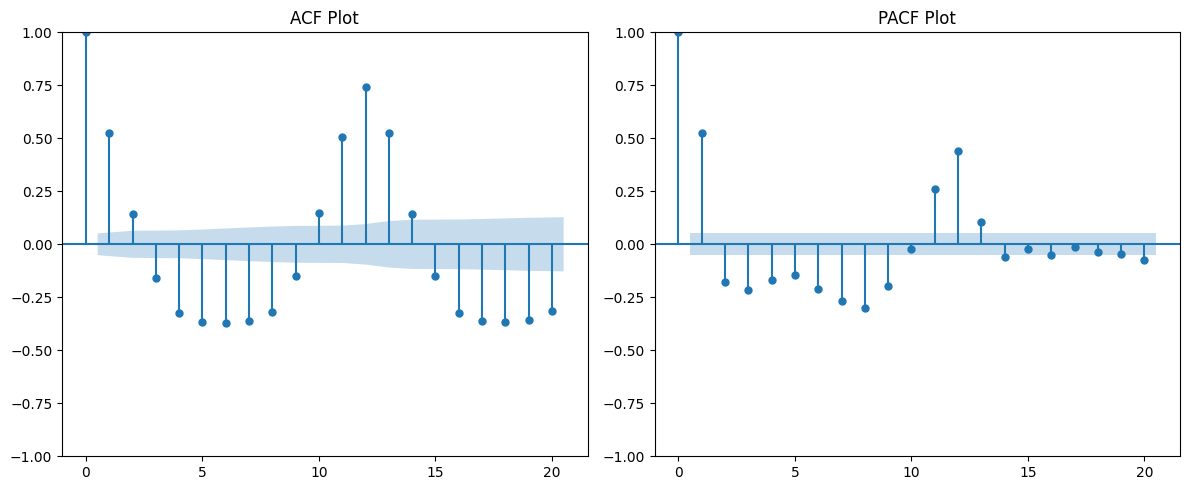

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

plot_acf(
    df_long['rainfall_mm'],
    lags=20,
    ax=axes[0]
)

axes[0].set_title('ACF Plot')

plot_pacf(
    df_long['rainfall_mm'],
    lags=20,
    ax=axes[1]
)

axes[1].set_title('PACF Plot')

plt.tight_layout()
plt.show()

## Feature Correlation Analysis

Analyze the relationship between engineered features and rainfall to identify the most influential predictors for forecasting model development.

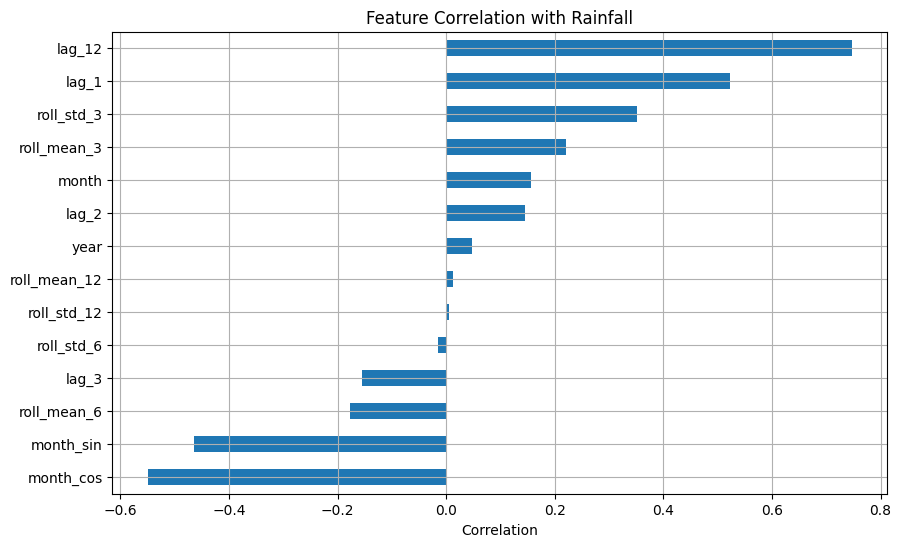

In [35]:
correlations = df_feat.corr()['rainfall_mm'].drop('rainfall_mm')
plt.figure(figsize=(10,6))
correlations.sort_values().plot(
    kind='barh'
)
plt.title(
    'Feature Correlation with Rainfall'
)

plt.xlabel('Correlation')

plt.grid(True)

plt.show()

## Modelling

Set up the dataset for model training, testing, and performance evaluation.

In [36]:
# Separate features and target variable
X = df_feat.drop(
    'rainfall_mm',
    axis=1
)

y = df_feat['rainfall_mm']

In [37]:
# Create time-based train-test split
X_train = X[:-24]
X_test  = X[-24:]

y_train = y[:-24]
y_test  = y[-24:]

print("X Train Shape:", X_train.shape)
print("X Test Shape :", X_test.shape)
print("Y Train Shape:", y_train.shape)
print("Y Test Shape :", y_test.shape)

X Train Shape: (1416, 14)
X Test Shape : (24, 14)
Y Train Shape: (1416,)
Y Test Shape : (24,)


In [38]:
# Define model evaluation function
def evaluate_model(model_name,y_true,y_pred):
    mae=mean_absolute_error(y_true,y_pred)
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(y_true, y_pred)

    print(
        f'{model_name:25s} | MAE={mae:7.2f} | RMSE={rmse:7.2f} | R2={r2:.3f}'
    )

# Results list
results = []

print("Evaluation function ready")

Evaluation function ready


## Model 1 - Seasonal Naive Baseline

In [39]:
naive_preds = np.tile(
    y_train.iloc[-12:].values,
    2
)[:len(y_test)]

# Negative values remove
naive_preds = np.clip(
    naive_preds,
    0,
    None
)

# Evaluate model
evaluate_model(
    'Seasonal Naive',
    y_test.values,
    naive_preds
)

Seasonal Naive            | MAE= 130.95 | RMSE= 234.82 | R2=0.656


## Model 2- RandomForest Regressor

In [40]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
rf_preds = rf_model.predict( X_test)

evaluate_model(
    'Random Forest',
    y_test.values,
    rf_preds
)

Random Forest             | MAE= 116.10 | RMSE= 203.64 | R2=0.741


## Model 3 - GradientBoosting Regressor

In [42]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [43]:
gb_preds = gb_model.predict(X_test)
evaluate_model(
    'Gradient Boosting',
    y_test.values,
    gb_preds
)

Gradient Boosting         | MAE= 126.36 | RMSE= 227.85 | R2=0.676


## Model 4 - XGBOOST

In [44]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [45]:
xgb_preds = xgb_model.predict(
    X_test
)

evaluate_model(
    'XGBoost',
    y_test.values,
    xgb_preds
)

XGBoost                   | MAE= 138.29 | RMSE= 254.26 | R2=0.596


## Model 5 - SARIMA

In [46]:
sarima_model = SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_fit = sarima_model.fit(
    disp=False
)

In [47]:
sarima_preds = sarima_fit.forecast(
    steps=len(y_test)
)

In [48]:
evaluate_model(
    'SARIMA',
    y_test.values,
    sarima_preds
)

SARIMA                    | MAE= 124.78 | RMSE= 212.71 | R2=0.718


## Model 6 -LSTM

In [49]:
# Scale rainfall data for LSTM training
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(
    df_feat[['rainfall_mm']]
)

In [50]:
# Create sequential input-output samples for time-series forecasting
def create_sequences(data,time_steps=12):
    X,y=[],[]
    for i in range (len(data)-time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])
    return np.array(X),np.array(y)

X, y = create_sequences(scaled_data, 12)

In [51]:
# Reshape input data into 3D format required for LSTM
X=X.reshape(
    X.shape[0],
    X.shape[1],
    1
)
print(X.shape)
print(y.shape)

(1428, 12, 1)
(1428, 1)


In [52]:
# Split sequential data into training and testing sets
split=int(0.8*len(X))
X_train_lstm,X_test_lstm=X[:split],X[split:]
y_train_lstm,y_test_lstm=y[:split],y[split:]

In [53]:
# Build LSTM deep learning model architecture
model_lstm=Sequential()
model_lstm.add(LSTM(64,return_sequences=True,input_shape=(12,1)))
model_lstm.add(Dropout(0.2))
model_lstm.add(LSTM(64))
model_lstm.add(Dropout(0.2))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam',loss='mse')
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 12, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
history=model_lstm.fit(
    X_train_lstm,y_train_lstm,
    epochs=20,
    batch_size=16,
    validation_data=(X_test_lstm,y_test_lstm)
)


Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.0357 - val_loss: 0.0332
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0237 - val_loss: 0.0290
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0205 - val_loss: 0.0235
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0185 - val_loss: 0.0222
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0188 - val_loss: 0.0273
Epoch 6/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0191 - val_loss: 0.0233
Epoch 7/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0192 - val_loss: 0.0308
Epoch 8/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0204 - val_loss: 0.0207
Epoch 9/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0183 - val_loss: 0.0239
Epoch 10/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0166 - val_loss: 0.0218
Epoch 11/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0173 - val_loss: 0.0231
Epoch 12/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0

In [55]:
lstm_pred=model_lstm.predict(X_test_lstm)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step


In [56]:
lstm_pred=scaler.inverse_transform(lstm_pred)
y_test_actual=scaler.inverse_transform(y_test_lstm)

In [57]:
evaluate_model(
    'LSTM',
    y_test_actual,
    lstm_pred
)

LSTM                      | MAE= 117.51 | RMSE= 207.11 | R2=0.595


In [58]:

# Seasonal Naive
baseline_mae = mean_absolute_error(y_test, naive_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_test, naive_preds))
baseline_r2 = r2_score(y_test, naive_preds)

# Random Forest
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

# Gradient Boosting
gb_mae = mean_absolute_error(y_test, gb_preds)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_r2 = r2_score(y_test, gb_preds)

# XGBoost
xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
xgb_r2 = r2_score(y_test, xgb_preds)

# SARIMA
sarima_mae = mean_absolute_error(y_test, sarima_preds)
sarima_rmse = np.sqrt(mean_squared_error(y_test, sarima_preds))
sarima_r2 = r2_score(y_test, sarima_preds)

#LSTM
lstm_mae = mean_absolute_error(y_test_actual,lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual,lstm_pred))
lstm_r2 = r2_score(y_test_actual,lstm_pred)

In [59]:
results_df = pd.DataFrame({
    'Model': [
        'Seasonal Naive',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost',
        'SARIMA',
        'LSTM'
    ],

    'MAE': [
        baseline_mae,
        rf_mae,
        gb_mae,
        xgb_mae,
        sarima_mae,
        lstm_mae
    ],

    'RMSE': [
        baseline_rmse,
        rf_rmse,
        gb_rmse,
        xgb_rmse,
        sarima_rmse,
        lstm_rmse 
    ],

    'R2 Score': [
        baseline_r2,
        rf_r2,
        gb_r2,
        xgb_r2,
        sarima_r2,
        lstm_r2 
    ]
})

print(
    results_df.sort_values(
        by='RMSE'
    )
)

               Model         MAE        RMSE  R2 Score
1      Random Forest  116.098382  203.635031  0.741175
5               LSTM  117.510478  207.114030  0.595140
4             SARIMA  124.781893  212.711007  0.717589
2  Gradient Boosting  126.355210  227.848186  0.675964
0     Seasonal Naive  130.946487  234.820023  0.655831
3            XGBoost  138.293173  254.257754  0.596494


# MODEL PERFORMANCE COMPARISON 

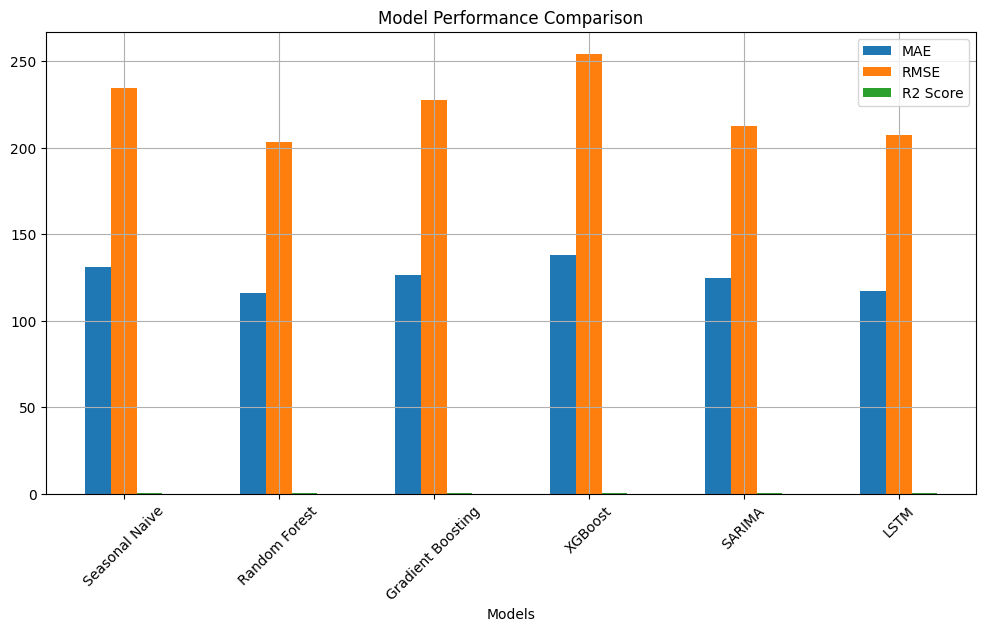

In [60]:
results_df.plot(
    x='Model',
    kind='bar',
    figsize=(12,6)
)

plt.title('Model Performance Comparison')
plt.xlabel('Models')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

##  Hyperparameter Tuning (Random Forest)

In [61]:
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Base model
rf = RandomForestRegressor(
    random_state=42
)

# Random Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

# Train
random_search.fit(
    X_train,
    y_train
)

# Best parameters
print(
    "Best Parameters:",
    random_search.best_params_
)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 30}


In [62]:
best_rf = random_search.best_estimator_

best_rf_preds = best_rf.predict(
    X_test
)

evaluate_model(
    'Randomized Tuned RF',
    y_test.values,
    best_rf_preds
)

Randomized Tuned RF       | MAE= 113.01 | RMSE= 199.17 | R2=0.752


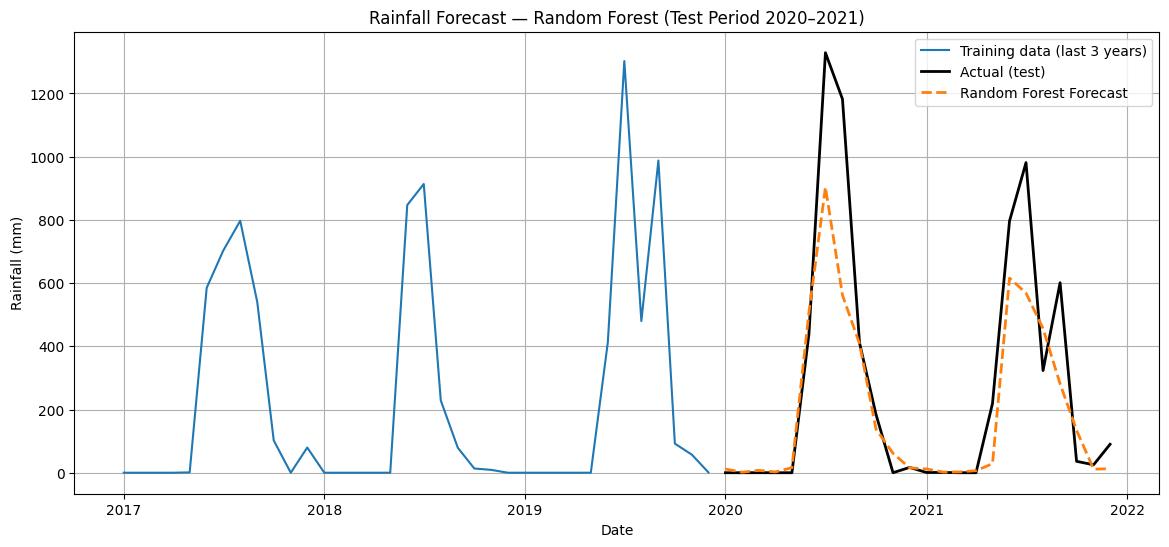

In [63]:
plt.figure(figsize=(14,6))

# Last 3 years training data
plt.plot(
    y_train[-36:],
    label='Training data (last 3 years)'
)

# Actual test
plt.plot(
    y_test,
    color='black',
    linewidth=2,
    label='Actual (test)'
)

# Predicted
plt.plot(
    y_test.index,
    best_rf_preds,
    '--',
    linewidth=2,
    label='Random Forest Forecast'
)

plt.title('Rainfall Forecast — Random Forest (Test Period 2020–2021)')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')

plt.legend()
plt.grid(True)

plt.show()

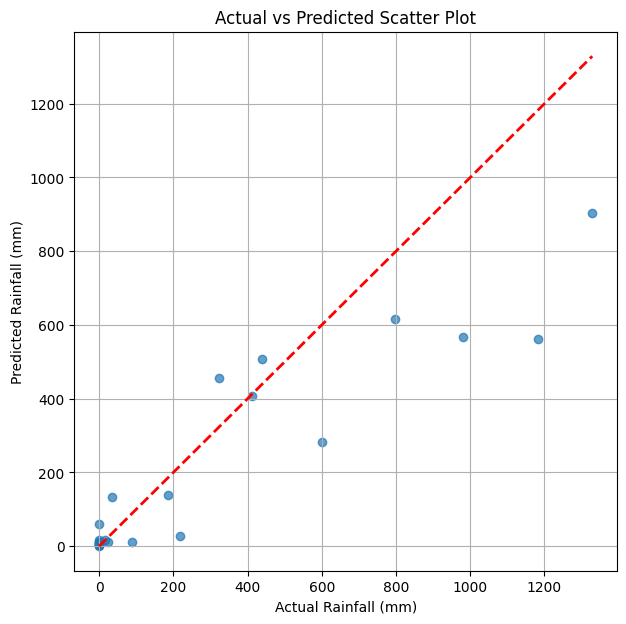

In [64]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    best_rf_preds,
    alpha=0.7
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.title('Actual vs Predicted Scatter Plot')
plt.xlabel('Actual Rainfall (mm)')
plt.ylabel('Predicted Rainfall (mm)')

plt.grid(True)

plt.show()

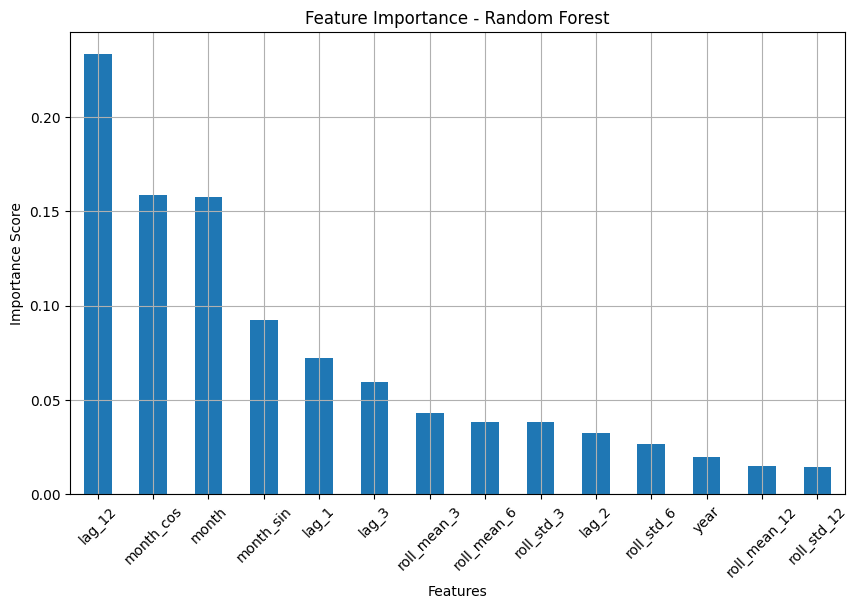

In [65]:
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

feature_importance.plot(
    kind='bar'
)

plt.title('Feature Importance - Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance Score')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

## Future Rainfall Forecasting

In [66]:
TARGET = 'rainfall_mm'

model = best_rf

print("Best model selected: Randomized Tuned Random Forest")
print("Model loaded successfully")

Best model selected: Randomized Tuned Random Forest
Model loaded successfully


In [67]:
X_all = df_feat.drop(
    'rainfall_mm',
    axis=1
)

y_all = df_feat['rainfall_mm']

best_rf.fit(
    X_all,
    y_all
)

print(
    f"Randomized Tuned Random Forest retrained on full dataset ({len(X_all)} months)"
)

Randomized Tuned Random Forest retrained on full dataset (1440 months)


## 12-Month Iterative Rainfall Forecast (2022)

In [68]:
future_data = df_feat.copy()

future_preds = []

for i in range(12):

    last_date = future_data.index[-1]
    next_date = last_date + pd.DateOffset(months=1)

    month = next_date.month
    year = next_date.year

    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    lag_1 = future_data['rainfall_mm'].iloc[-1]
    lag_2 = future_data['rainfall_mm'].iloc[-2]
    lag_3 = future_data['rainfall_mm'].iloc[-3]
    lag_12 = future_data['rainfall_mm'].iloc[-12]

    roll_mean_3 = future_data['rainfall_mm'].iloc[-3:].mean()
    roll_std_3 = future_data['rainfall_mm'].iloc[-3:].std()

    roll_mean_6 = future_data['rainfall_mm'].iloc[-6:].mean()
    roll_std_6 = future_data['rainfall_mm'].iloc[-6:].std()

    roll_mean_12 = future_data['rainfall_mm'].iloc[-12:].mean()
    roll_std_12 = future_data['rainfall_mm'].iloc[-12:].std()

    next_row = pd.DataFrame({
        'year': [year],
        'month': [month],
        'month_sin': [month_sin],
        'month_cos': [month_cos],
        'lag_1': [lag_1],
        'lag_2': [lag_2],
        'lag_3': [lag_3],
        'lag_12': [lag_12],
        'roll_mean_3': [roll_mean_3],
        'roll_std_3': [roll_std_3],
        'roll_mean_6': [roll_mean_6],
        'roll_std_6': [roll_std_6],
        'roll_mean_12': [roll_mean_12],
        'roll_std_12': [roll_std_12]
    }, index=[next_date])

    pred = best_rf.predict(
        next_row[X_all.columns]
    )[0]

    future_preds.append(pred)

    next_row['rainfall_mm'] = pred

    future_data = pd.concat([future_data, next_row])

In [69]:
future_dates = pd.date_range(
    start=df_feat.index[-1] + pd.DateOffset(months=1),
    periods=len(future_preds),
    freq='MS'
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted Rainfall (mm)': future_preds
})

print(forecast_df)

         Date  Predicted Rainfall (mm)
0  2022-01-01                 5.067031
1  2022-02-01                 5.861716
2  2022-03-01                 4.953448
3  2022-04-01                 8.263396
4  2022-05-01               169.747794
5  2022-06-01               664.954006
6  2022-07-01               758.317235
7  2022-08-01               491.197252
8  2022-09-01               423.100879
9  2022-10-01                97.939291
10 2022-11-01                33.139252
11 2022-12-01                20.200782


## Forecast vs Historical Context

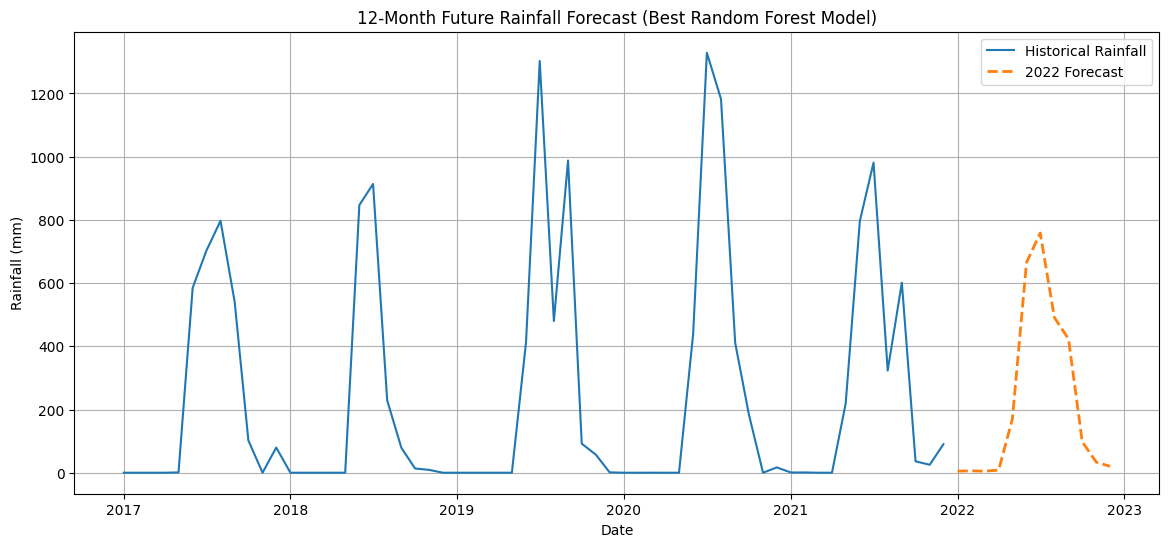

In [70]:
plt.figure(figsize=(14,6))

plt.plot(
    df_feat['rainfall_mm'][-60:],
    label='Historical Rainfall'
)

plt.plot(
    future_dates,
    future_preds,
    '--',
    linewidth=2,
    label='2022 Forecast'
)

plt.title('12-Month Future Rainfall Forecast (Best Random Forest Model)')

plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')

plt.legend()
plt.grid(True)

plt.show()

## Forecast vs Historical Monthly Average

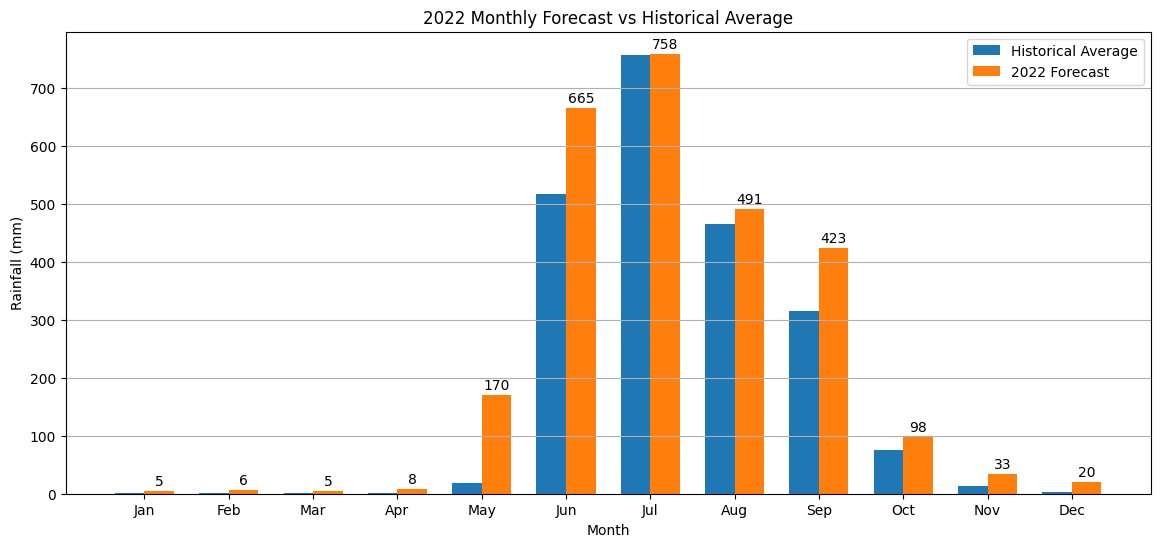

In [71]:
hist_monthly_avg = df_feat.groupby(
    df_feat.index.month
)['rainfall_mm'].mean()

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

x = np.arange(12)
width = 0.35

plt.figure(figsize=(14,6))

plt.bar(
    x - width/2,
    hist_monthly_avg.values,
    width,
    label='Historical Average'
)

plt.bar(
    x + width/2,
    forecast_df['Predicted Rainfall (mm)'],
    width,
    label='2022 Forecast'
)
for i, v in enumerate(forecast_df['Predicted Rainfall (mm)']):
    plt.text(
        i + width/2,
        v + 10,
        f'{v:.0f}',
        ha='center'
    )

plt.xticks(x, months)

plt.title('2022 Monthly Forecast vs Historical Average')

plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')

plt.legend()
plt.grid(axis='y')

plt.show()

## Forecast Summary Statistics

In [72]:
total_forecast = forecast_df['Predicted Rainfall (mm)'].sum()

peak = forecast_df.loc[
    forecast_df['Predicted Rainfall (mm)'].idxmax()
]

dry = forecast_df.loc[
    forecast_df['Predicted Rainfall (mm)'].idxmin()
]

print("2022 Forecast Summary")
print("Total Forecasted Rainfall:", round(total_forecast), "mm")

print(
    "Peak Month:",
    peak['Date'].strftime('%B %Y'),
    "-",
    round(peak['Predicted Rainfall (mm)']),
    "mm"
)

print(
    "Driest Month:",
    dry['Date'].strftime('%B %Y'),
    "-",
    round(dry['Predicted Rainfall (mm)']),
    "mm"
)

2022 Forecast Summary
Total Forecasted Rainfall: 2683 mm
Peak Month: July 2022 - 758 mm
Driest Month: March 2022 - 5 mm


## Shap Analysis

In [73]:
explainer = shap.TreeExplainer(best_rf)

shap_values = explainer.shap_values(X_test)

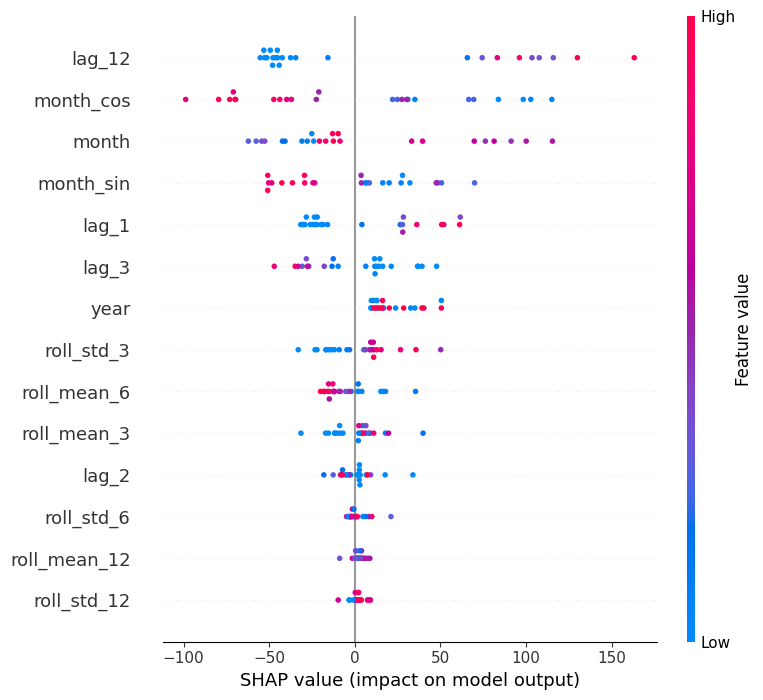

In [74]:
shap.summary_plot(
    shap_values,
    X_test
)

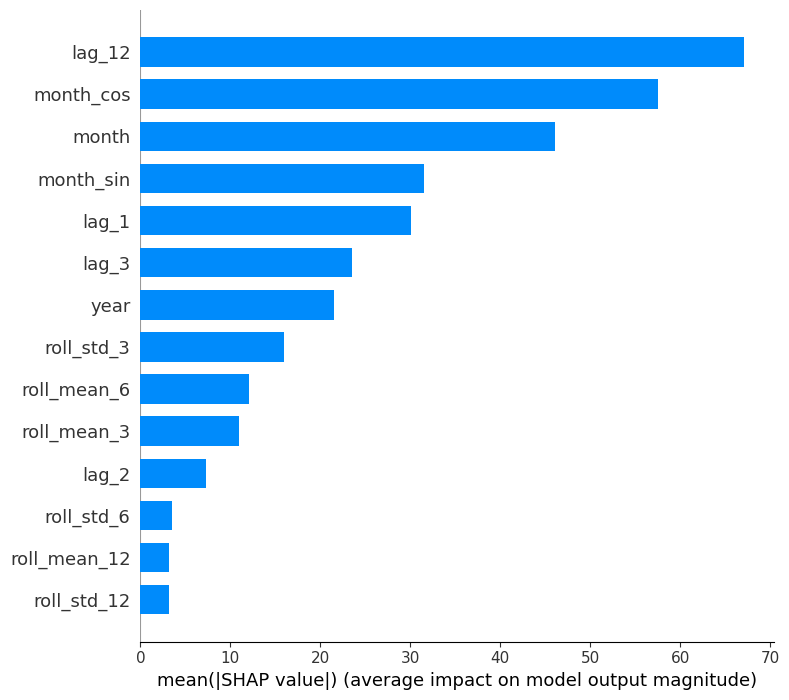

In [75]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar'
)

## Model saved

In [76]:
joblib.dump(
    best_rf,
    'rainfall_forecast_rf.pkl'
)

print('Model saved successfully')

Model saved successfully


## Conclusion
Random Forest achieved RMSE 203.63 mm and R² 0.741 — best of 6 models
Lag features & cyclical month encoding drive model accuracy.
2022 forecast: above-average monsoon season predicted.